In [2]:
import pandas as pd

# Define the path to your CSV file
file_path = '/kaggle/input/match-gpt/matchs_gpt.csv'

# Load the entire CSV into a DataFrame
try:
    df = pd.read_csv(file_path)
    
    # Print the first 5 rows to verify it loaded correctly
    print(df.head(1))
    
    # Print the shape (rows, columns) of the DataFrame
    print(f"Successfully loaded DataFrame with shape: {df.shape}")
    
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")

                                     id                     model_a  \
0  e67468c9-69b7-4b84-9ec2-27879128c4c6  chatgpt-4o-latest-20250326   

            model_b   winner                 evaluation_session_id  \
0  grok-3-mini-beta  model_b  f17a411e-0b72-462b-89b6-66da06088c24   

   evaluation_order                                     conversation_a  \
0                 1  [{'role': 'user', 'content': array([{'type': '...   

                                      conversation_b  \
0  [{'role': 'user', 'content': array([{'type': '...   

                                   full_conversation  \
0  [{'user': {'role': 'user', 'content': array([{...   

                                       conv_metadata  ...  \
0  {'sum_assistant_a_tokens': 491, 'header_count_...  ...   

                                          response_b  \
0  Yes, exercising until you feel a slight muscle...   

                                         user_prompt  gpt_in_a gpt_in_b  \
0  If I exercise until I feel 

In [5]:
df.columns

Index(['id', 'model_a', 'model_b', 'winner', 'evaluation_session_id',
       'evaluation_order', 'conversation_a', 'conversation_b',
       'full_conversation', 'conv_metadata', 'category_tag', 'language',
       'is_code', 'timestamp', 'turns', 'response_a', 'response_b',
       'user_prompt', 'gpt_in_a', 'gpt_in_b', 'gemini_in_a', 'gemini_in_b',
       'grok_in_a', 'grok_in_b', 'claude_in_a', 'claude_in_b'],
      dtype='object')

In [28]:
df = df.drop(["evaluation_session_id","evaluation_order","full_conversation","turns","conversation_b","conversation_a"],axis=1)

In [29]:
df.columns

Index(['id', 'model_a', 'model_b', 'winner', 'conv_metadata', 'category_tag',
       'language', 'is_code', 'timestamp', 'response_a', 'response_b',
       'user_prompt', 'gpt_in_a', 'gpt_in_b', 'gemini_in_a', 'gemini_in_b',
       'grok_in_a', 'grok_in_b', 'claude_in_a', 'claude_in_b'],
      dtype='object')

In [40]:
print(df["gemini_in_b"].sum())
print(df["gemini_in_a"].sum())
print(df["gpt_in_b"].sum())
print(df["gpt_in_a"].sum())
print(df["grok_in_b"].sum())
print(df["grok_in_a"].sum())
print(df["claude_in_b"].sum())
print(df["claude_in_a"].sum())

457
425
7419
7394
226
224
447
440


In [45]:
df["model_a"].unique()

array(['chatgpt-4o-latest-20250326', 'gpt-4.1-2025-04-14',
       'command-a-03-2025', 'o3-mini', 'o3-2025-04-16',
       'claude-opus-4-20250514', 'gemini-2.5-pro-preview-03-25',
       'claude-3-7-sonnet-20250219-thinking-32k',
       'claude-3-7-sonnet-20250219', 'magistral-medium-2506',
       'mistral-medium-2505', 'gemini-2.5-pro',
       'llama-4-maverick-03-26-experimental', 'gemini-2.0-flash-001',
       'deepseek-v3-0324', 'claude-3-5-haiku-20241022',
       'claude-sonnet-4-20250514-thinking-32k',
       'claude-sonnet-4-20250514', 'gpt-4o-2024-11-20',
       'mistral-small-3.1-24b-instruct-2503',
       'llama-4-maverick-17b-128e-instruct', 'gpt-4.1-mini-2025-04-14',
       'gemini-2.5-flash-lite-preview-06-17-thinking',
       'qwen3-235b-a22b-no-thinking', 'qwq-32b', 'mistral-small-2506',
       'gemma-3-27b-it', 'grok-3-preview-02-24', 'qwen-max-2025-01-25',
       'deepseek-r1-0528', 'gemini-2.5-flash', 'llama-3.3-70b-instruct',
       'claude-3-5-sonnet-20241022', 'gro

In [25]:
df.loc[0, "response_a"]

"Yes, feeling some **muscle fatigue** or a **mild ache** after exercise—especially something like walking 8,000 to 10,000 steps—can indeed be a sign that you've done **enough for that session**, depending on your fitness goals, current fitness level, and overall health.\n\nLet’s break it down:\n\n---\n\n## ✅ What Your Body Is Telling You\n\n- **Muscle tiredness** or a **mild ache** (not sharp or lingering pain) usually means you've **used your muscles enough** to stimulate them.\n- This is particularly true for **low-impact, endurance exercises** like walking. If you’re feeling leg fatigue at 8–10K steps, your muscles are working and adapting.\n\n---\n\n## 💡 Is This Enough For Exercise?\n\n### ✔ For General Health:\nYes — walking 8,000 to 10,000 steps **daily or most days** is great for:\n- Cardiovascular health\n- Weight management\n- Mental health\n- Longevity\n- Preventing lifestyle diseases\n\n### ✔ For Active Recovery or Low-Intensity Days:\nPerfect. A bit of fatigue is good; you’

In [3]:
df.iloc[0, 6]

'[{\'role\': \'user\', \'content\': array([{\'type\': \'text\', \'text\': \'If I exercise until I feel that the muscle aches (though just a bit, no strong pain), is that enough for an exercise session? Especially by walking, when I feel the legs tired (after 8 to 10k steps says the phone), I call it a day.\', \'image\': None, \'mimeType\': None}],\n       dtype=object)}\n {\'role\': \'assistant\', \'content\': array([{\'type\': \'text\', \'text\': "Yes, feeling some **muscle fatigue** or a **mild ache** after exercise—especially something like walking 8,000 to 10,000 steps—can indeed be a sign that you\'ve done **enough for that session**, depending on your fitness goals, current fitness level, and overall health.\\n\\nLet’s break it down:\\n\\n---\\n\\n## ✅ What Your Body Is Telling You\\n\\n- **Muscle tiredness** or a **mild ache** (not sharp or lingering pain) usually means you\'ve **used your muscles enough** to stimulate them.\\n- This is particularly true for **low-impact, endura

In [18]:
print(df[["timestamp"]].head(10))


                    timestamp
0  2025-05-07 22:23:19.129624
1  2025-07-10 14:35:11.747814
2  2025-06-08 09:39:43.361082
3  2025-05-13 07:31:46.790543
4  2025-04-18 21:54:13.282072
5  2025-04-23 05:43:38.606295
6  2025-07-15 07:42:26.625417
7  2025-07-10 09:07:49.286073
8  2025-05-25 12:29:32.683028
9  2025-05-30 07:46:50.694157


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


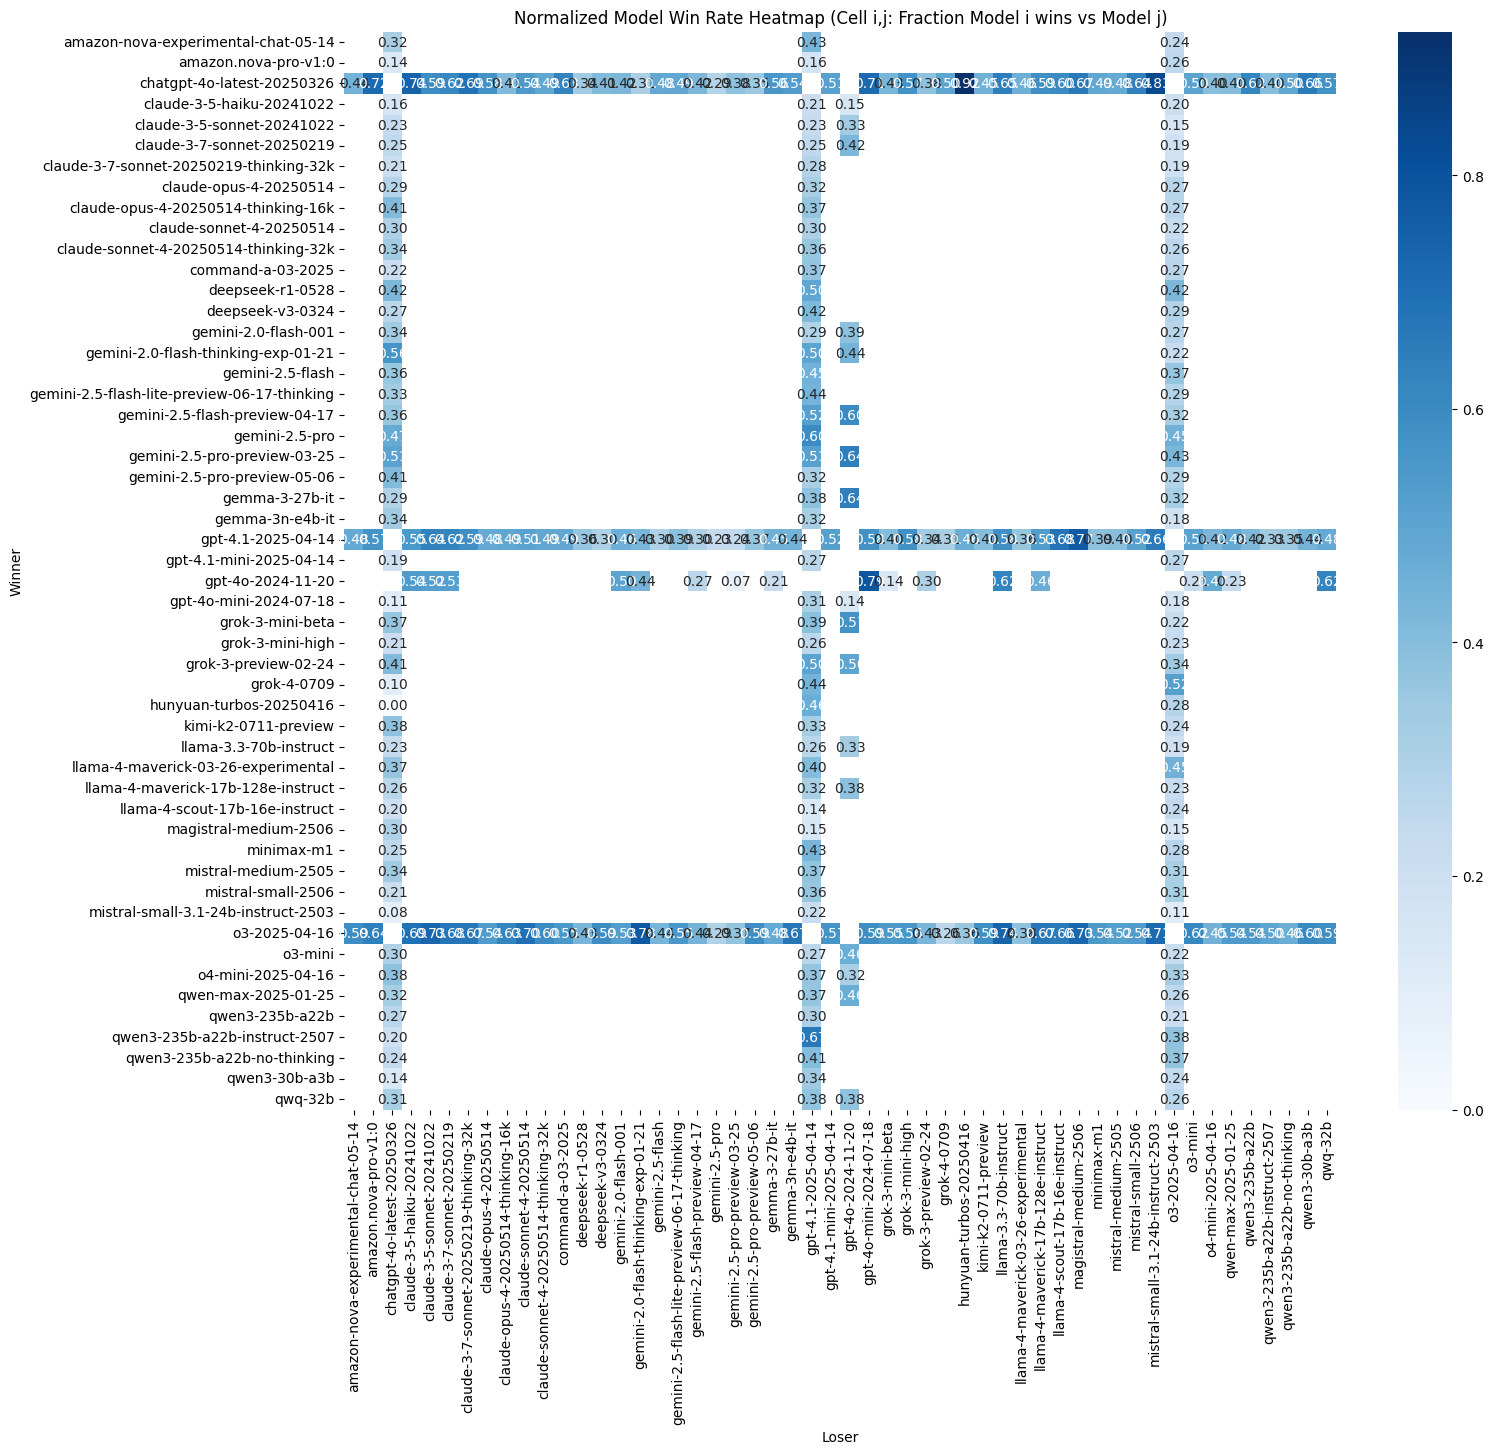

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Assume your DataFrame is named df and is already loaded

models = np.unique(df[['model_a', 'model_b']].values)
win_matrix = pd.DataFrame(0, index=models, columns=models)
game_count_matrix = pd.DataFrame(0, index=models, columns=models)

for _, row in df.iterrows():
    # Only count cases where a game was played (ignore 'both_bad' if you wish)
    if row['winner'] in ['model_a', 'model_b', 'tie']:
        game_count_matrix.loc[row['model_a'], row['model_b']] += 1
        game_count_matrix.loc[row['model_b'], row['model_a']] += 1
    if row['winner'] == 'model_a':
        win_matrix.loc[row['model_a'], row['model_b']] += 1
    elif row['winner'] == 'model_b':
        win_matrix.loc[row['model_b'], row['model_a']] += 1

# Normalize: divide wins by total games per pair
normalized_win_matrix = win_matrix / game_count_matrix.replace(0, np.nan)  # Avoid division by zero

plt.figure(figsize=(16, 14))
sns.heatmap(normalized_win_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.title('Normalized Model Win Rate Heatmap (Cell i,j: Fraction Model i wins vs Model j)')
plt.ylabel('Winner')
plt.xlabel('Loser')
plt.show()


         Current function value: 0.633488
         Iterations: 35
amazon-nova-experimental-chat-05-14             0.021876
amazon.nova-pro-v1:0                           -0.627934
chatgpt-4o-latest-20250326                      0.561911
claude-3-5-haiku-20241022                      -0.757044
claude-3-5-sonnet-20241022                     -0.635357
claude-3-7-sonnet-20250219                     -0.475783
claude-3-7-sonnet-20250219-thinking-32k        -0.544956
claude-opus-4-20250514                         -0.082859
claude-opus-4-20250514-thinking-16k             0.081704
claude-sonnet-4-20250514                       -0.250264
claude-sonnet-4-20250514-thinking-32k          -0.004197
command-a-03-2025                              -0.160397
deepseek-r1-0528                                0.657333
deepseek-v3-0324                                0.193007
gemini-2.0-flash-001                            0.025042
gemini-2.0-flash-thinking-exp-01-21             0.328659
gemini-2.5-flash      

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


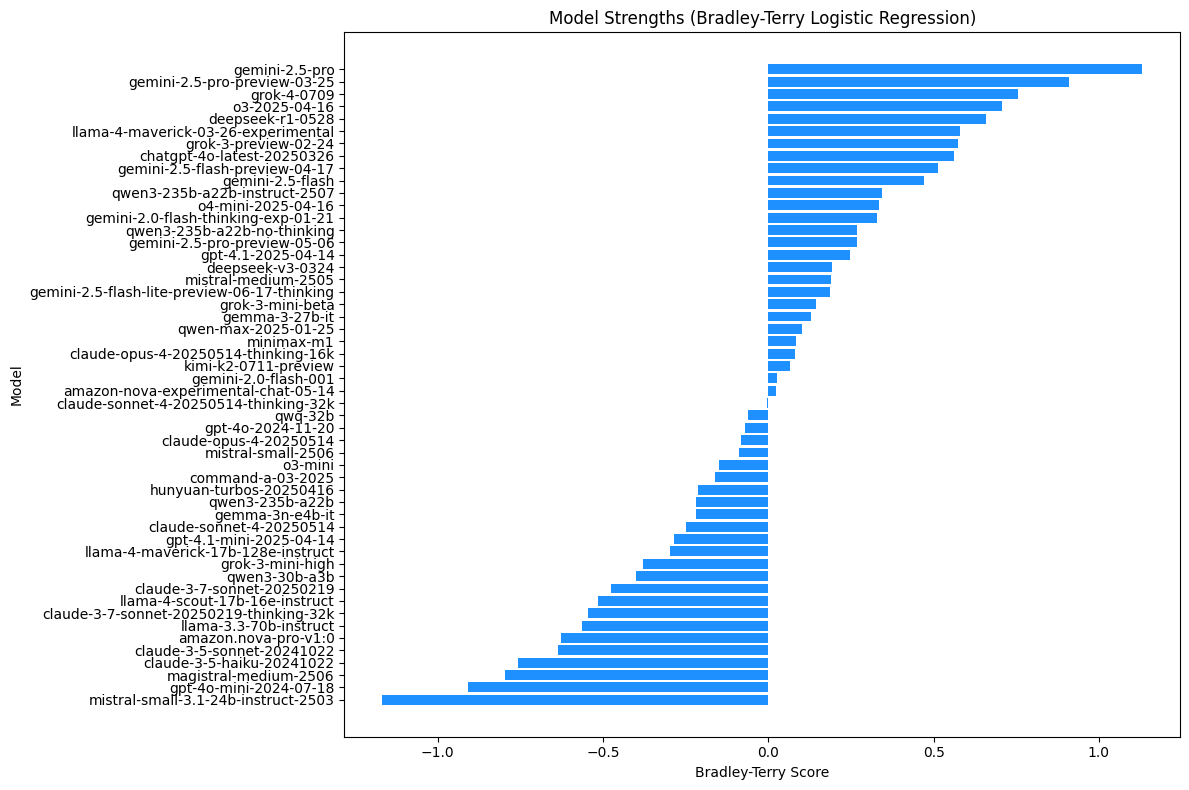

In [10]:
import pandas as pd
wins = []

for i in win_matrix.index:
    for j in win_matrix.columns:
        if i != j:
            # Each win is a row
            wins += [{"winner": i, "loser": j}] * win_matrix.loc[i, j]

bt_df = pd.DataFrame(wins)


import statsmodels.api as sm
import numpy as np

# Assign integer IDs to each model for the regression
model_ids = {model: idx for idx, model in enumerate(win_matrix.index)}
bt_df['winner_id'] = bt_df['winner'].map(model_ids)
bt_df['loser_id'] = bt_df['loser'].map(model_ids)

# Prepare design matrix for pairwise logistic regression
n_models = len(model_ids)
X = np.zeros((len(bt_df), n_models))
y = np.ones(len(bt_df))

for idx, row in bt_df.iterrows():
    X[idx, row['winner_id']] = 1
    X[idx, row['loser_id']] = -1

# Fit logistic regression with no intercept (constrain sum to zero)
model = sm.Logit(y, X)
result = model.fit()
scores_logistic = result.params
bt_scores = pd.Series(scores_logistic, index=win_matrix.index)
print(bt_scores)

# bt_scores is a pd.Series from your previous output
sorted_scores = bt_scores.sort_values(ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(sorted_scores.index, sorted_scores.values, color='dodgerblue')
plt.xlabel('Bradley-Terry Score')
plt.ylabel('Model')
plt.title('Model Strengths (Bradley-Terry Logistic Regression)')
plt.gca().invert_yaxis()  # so strongest at the top
plt.tight_layout()
plt.show()


/tmp/ipykernel_37/1762291430.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1497.4736842105262' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  elo[i] += K * (actual_i - expected_i)


amazon-nova-experimental-chat-05-14             1510.446793
amazon.nova-pro-v1:0                            1385.890191
chatgpt-4o-latest-20250326                      1614.058064
claude-3-5-haiku-20241022                       1352.136157
claude-3-5-sonnet-20241022                      1394.577987
claude-3-7-sonnet-20250219                      1422.479315
claude-3-7-sonnet-20250219-thinking-32k         1414.801685
claude-opus-4-20250514                          1485.928459
claude-opus-4-20250514-thinking-16k             1519.773729
claude-sonnet-4-20250514                        1460.396065
claude-sonnet-4-20250514-thinking-32k           1500.598460
command-a-03-2025                               1473.680174
deepseek-r1-0528                                1608.530313
deepseek-v3-0324                                1539.620216
gemini-2.0-flash-001                            1490.922499
gemini-2.0-flash-thinking-exp-01-21             1537.655458
gemini-2.5-flash                        

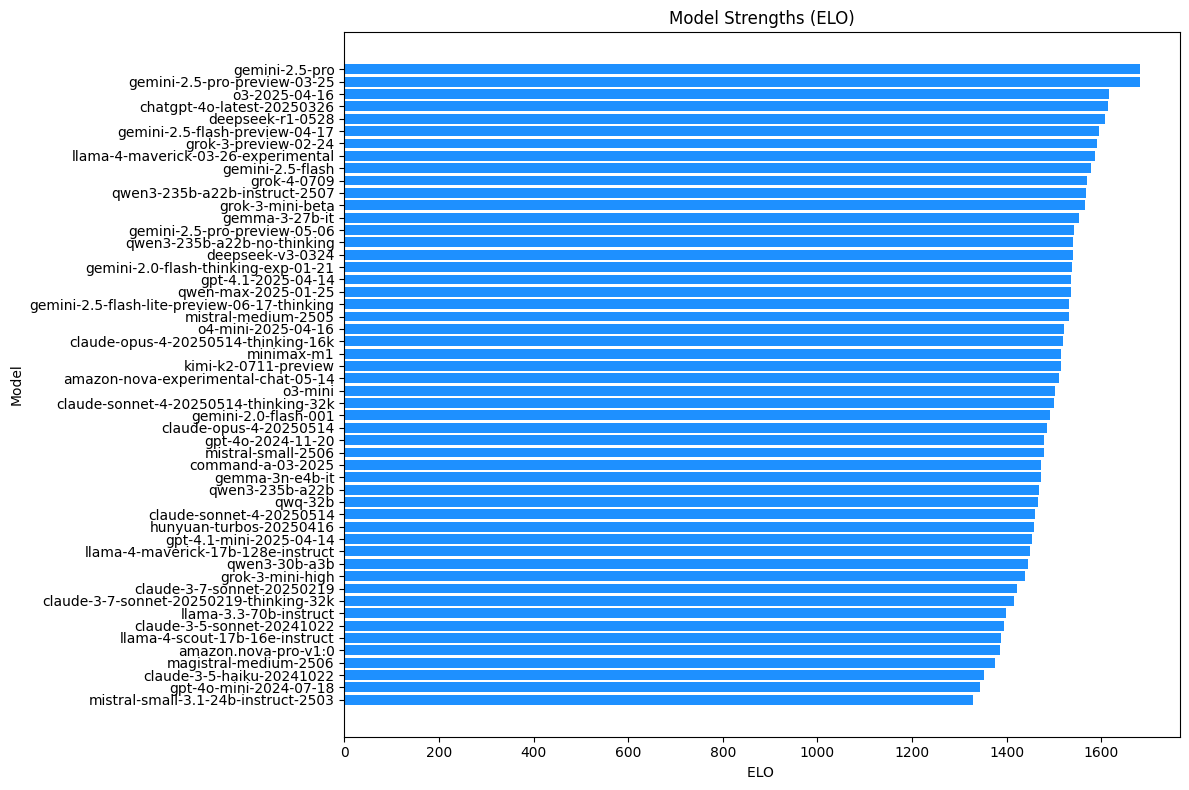

In [12]:
# Initialize ELO ratings
elo = pd.Series(1500, index=win_matrix.index)
K = 32

for _ in range(20):  # Multiple iterations for convergence
    for i in win_matrix.index:
        for j in win_matrix.columns:
            if i != j:
                wins_ij = win_matrix.loc[i, j]
                wins_ji = win_matrix.loc[j, i]
                total_games = wins_ij + wins_ji
                if total_games > 0:
                    expected_i = 1 / (1 + 10 ** ((elo[j] - elo[i]) / 400))
                    actual_i = wins_ij / total_games
                    elo[i] += K * (actual_i - expected_i)

print(elo)

# bt_scores is a pd.Series from your previous output
sorted_scores = elo.sort_values(ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(sorted_scores.index, sorted_scores.values, color='dodgerblue')
plt.xlabel('ELO ')
plt.ylabel('Model')
plt.title('Model Strengths (ELO)')
plt.gca().invert_yaxis()  # so strongest at the top
plt.tight_layout()
plt.show()


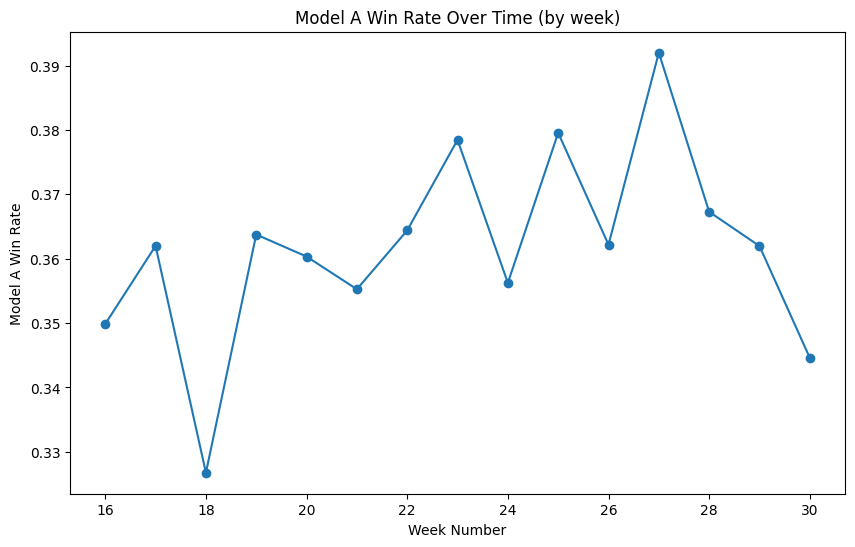

AttributeError: 'Series' object has no attribute 'append'

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Assume df contains 'timestamp', 'winner', 'model_a', 'model_b'
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sort by time for time-series analysis
df = df.sort_values('timestamp')

# Extract features
df['date'] = df['timestamp'].dt.date
df['month'] = df['timestamp'].dt.month
df['week'] = df['timestamp'].dt.isocalendar().week
df['day'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour

# WINNER: extract win for model_a
df['model_a_win'] = (df['winner'] == 'model_a').astype(int)
df['model_b_win'] = (df['winner'] == 'model_b').astype(int)

# Aggregate win rates over time: e.g., by week for all models
win_rate_by_week = df.groupby('week')['model_a_win'].mean()

plt.figure(figsize=(10,6))
plt.plot(win_rate_by_week.index, win_rate_by_week.values, marker='o')
plt.xlabel('Week Number')
plt.ylabel('Model A Win Rate')
plt.title('Model A Win Rate Over Time (by week)')
plt.show()

# To analyze for all models:
# For each model, compute win rate over time
for model in pd.unique(df['model_a'].append(df['model_b'])):
    tmp = df[((df['model_a'] == model) | (df['model_b'] == model))]
    # Wins where model is model_a or model_b
    tmp['win'] = ((tmp['model_a'] == model) & (tmp['winner'] == 'model_a')) | ((tmp['model_b'] == model) & (tmp['winner'] == 'model_b'))
    win_rate = tmp.groupby('week')['win'].mean()
    plt.plot(win_rate.index, win_rate.values, label=model)

plt.xlabel('Week Number')
plt.ylabel('Win Rate')
plt.title('Model Win Rates Over Time')
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


In [20]:
import statsmodels.formula.api as smf

# Example: does time predict model_a's win?
df['week_num'] = df['week'].astype(int)  # statsmodels needs int
result = smf.logit('model_a_win ~ week_num', data=df).fit()
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.655925
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:            model_a_win   No. Observations:                14813
Model:                          Logit   Df Residuals:                    14811
Method:                           MLE   Df Model:                            1
Date:                Fri, 07 Nov 2025   Pseudo R-squ.:               9.588e-05
Time:                        11:08:02   Log-Likelihood:                -9716.2
converged:                       True   LL-Null:                       -9717.2
Covariance Type:            nonrobust   LLR p-value:                    0.1722
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.6878      0.098     -6.993      0.000      -0.881      -0.495
week_num       0.0056      0.

/tmp/ipykernel_37/436316544.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


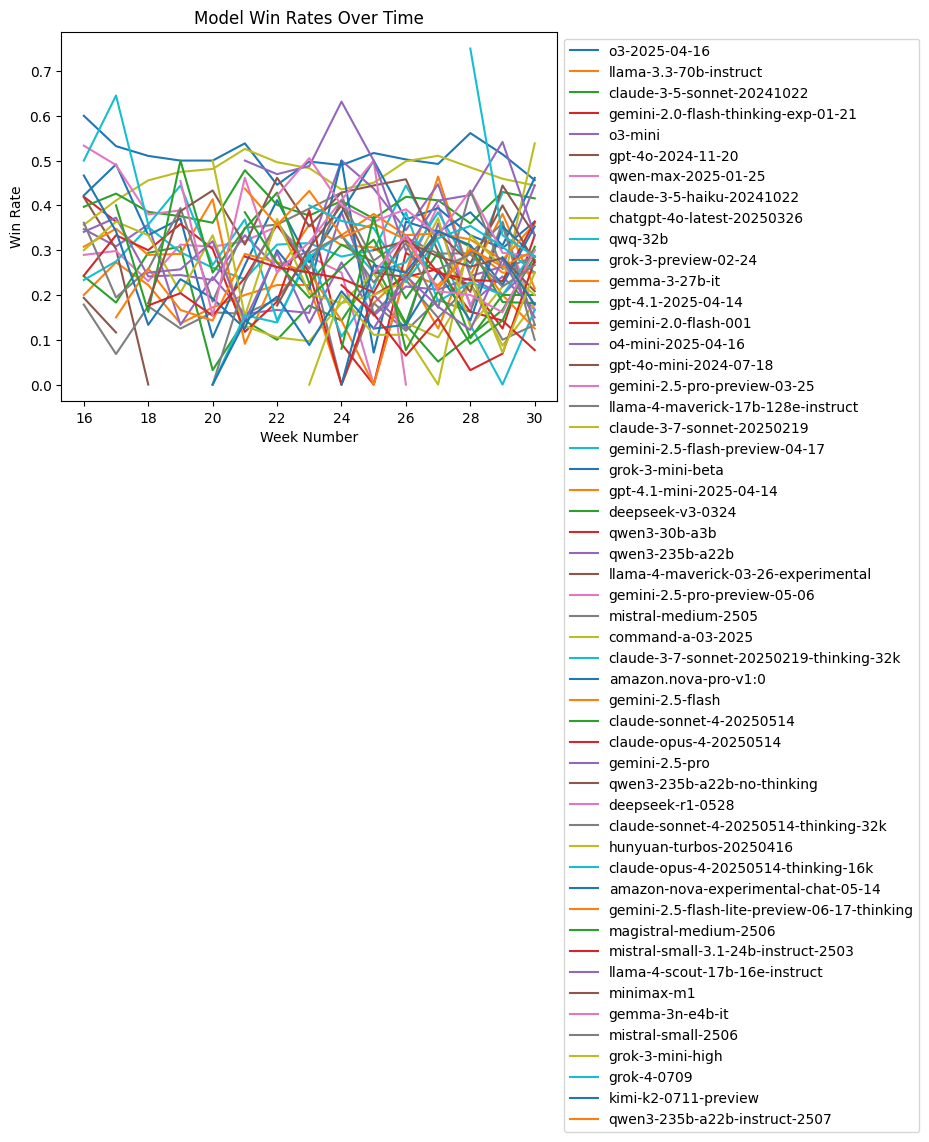

In [21]:
# To analyze for all models: 
# For each model, compute win rate over time
all_models = pd.unique(pd.concat([df['model_a'], df['model_b']]))

for model in all_models:
    tmp = df[((df['model_a'] == model) | (df['model_b'] == model))].copy()
    # Wins where model is model_a or model_b
    tmp['win'] = ((tmp['model_a'] == model) & (tmp['winner'] == 'model_a')) | ((tmp['model_b'] == model) & (tmp['winner'] == 'model_b'))
    win_rate = tmp.groupby('week')['win'].mean()
    plt.plot(win_rate.index, win_rate.values, label=model)

plt.xlabel('Week Number')
plt.ylabel('Win Rate')
plt.title('Model Win Rates Over Time')
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


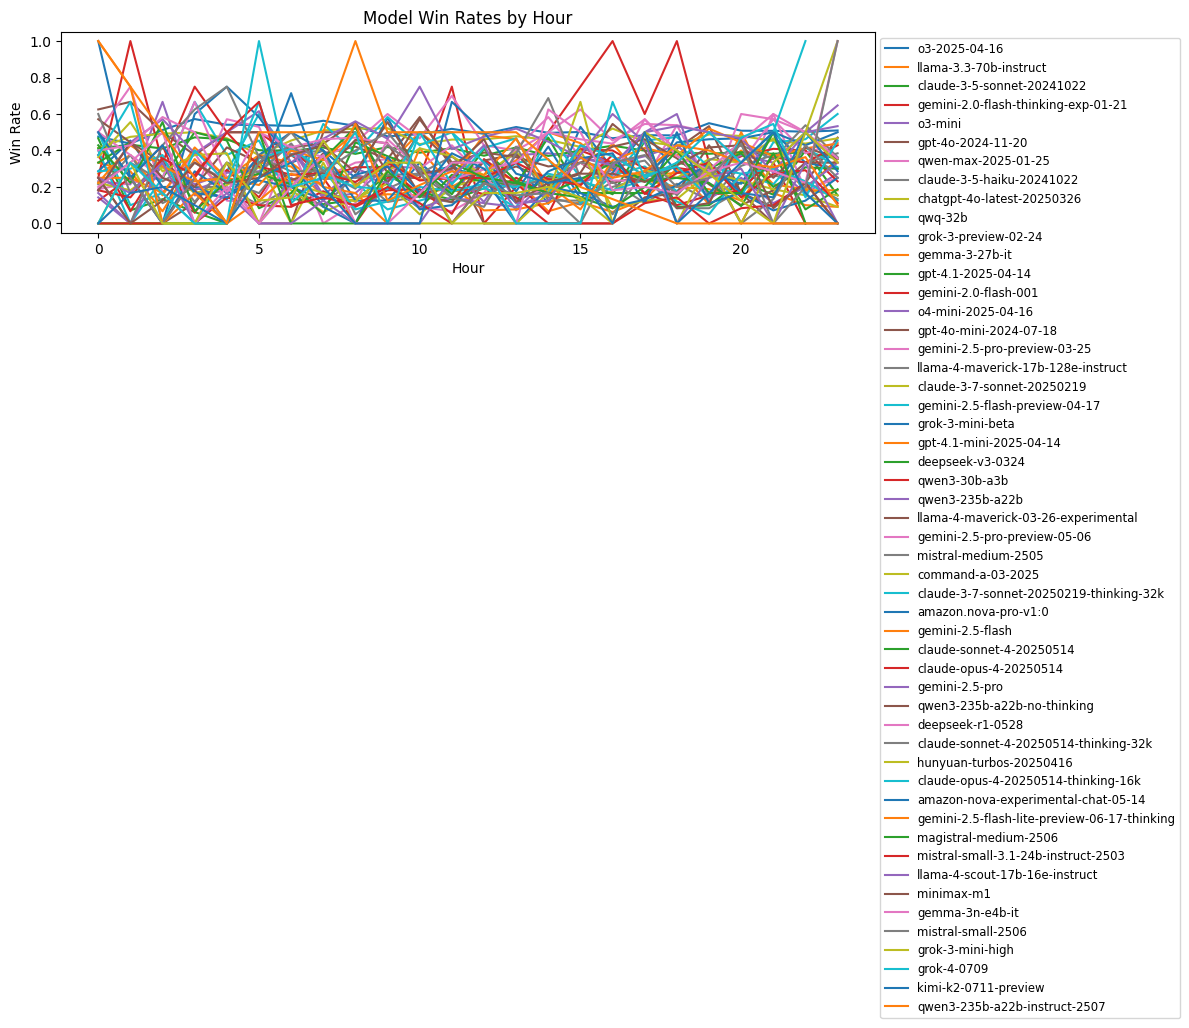

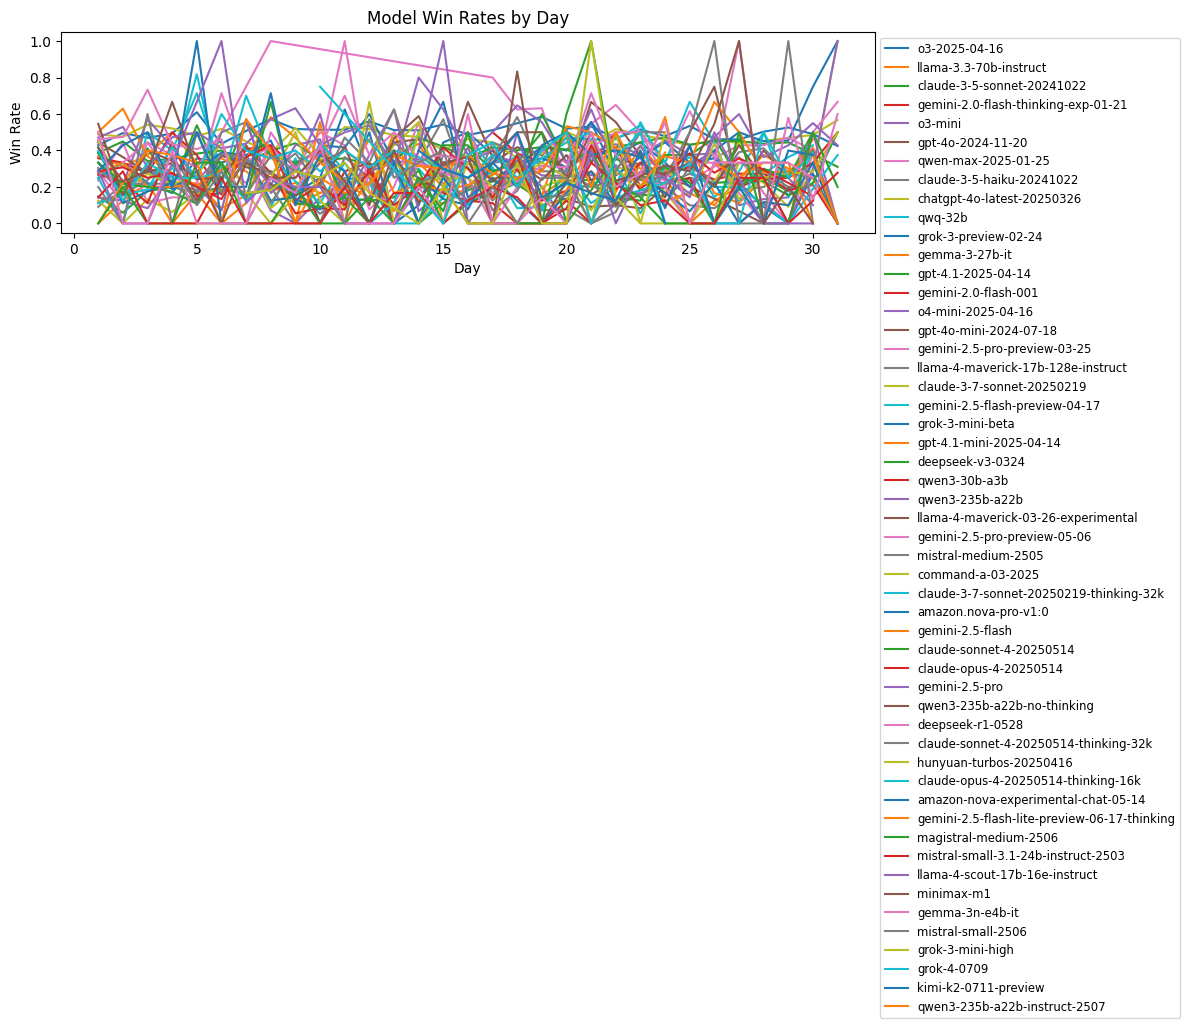

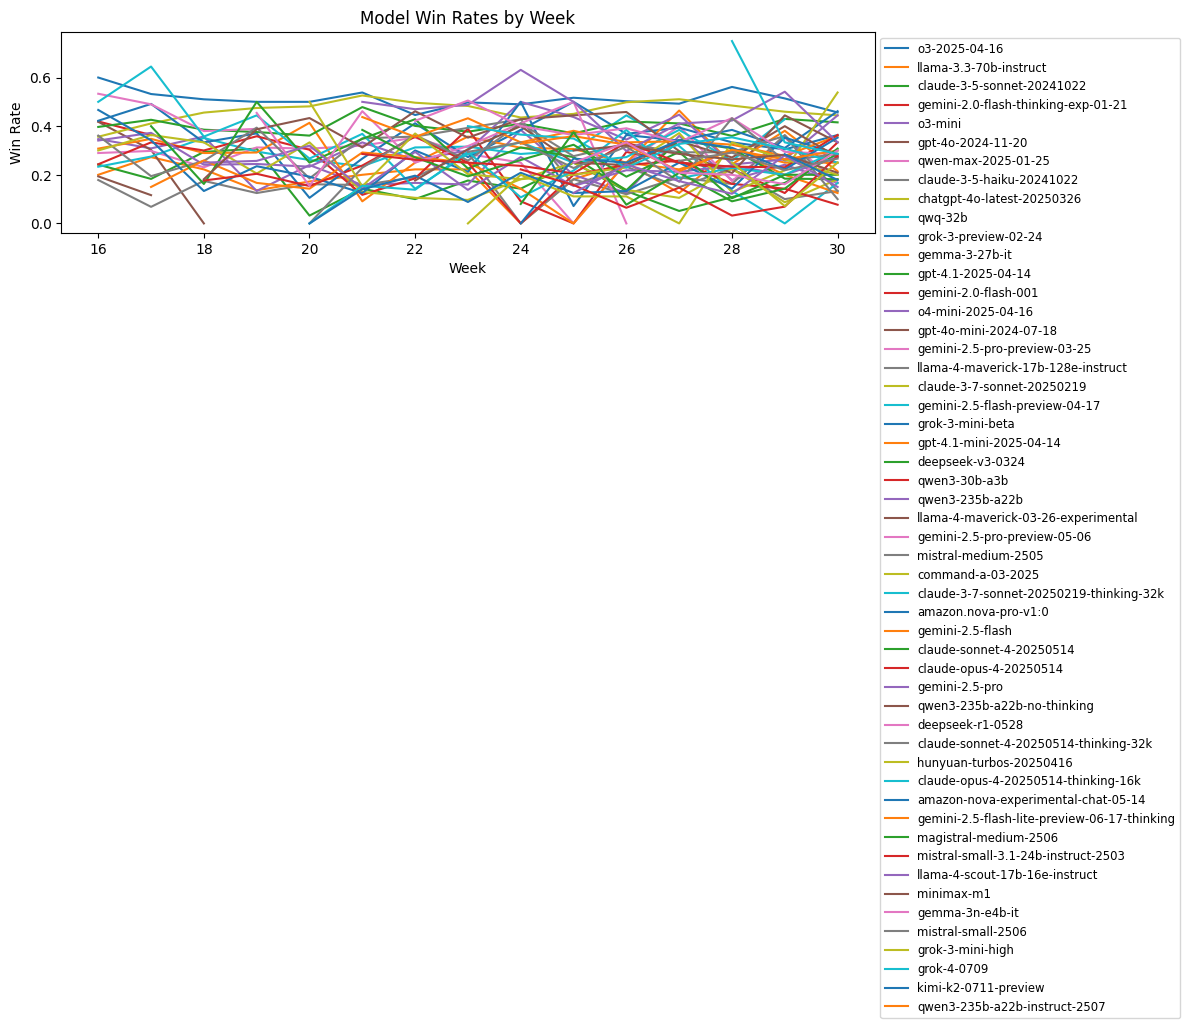

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# All model list as before
all_models = pd.unique(pd.concat([df['model_a'], df['model_b']]))

# For week, day, hour: loop over feature
for time_unit in ['hour', 'day', 'week']:
    plt.figure(figsize=(12,7))
    for model in all_models:
        tmp = df[((df['model_a'] == model) | (df['model_b'] == model))].copy()
        tmp['win'] = ((tmp['model_a'] == model) & (tmp['winner'] == 'model_a')) | \
                     ((tmp['model_b'] == model) & (tmp['winner'] == 'model_b'))
        win_rate = tmp.groupby(time_unit)['win'].mean()
        plt.plot(win_rate.index, win_rate.values, label=model)
    plt.xlabel(time_unit.capitalize())
    plt.ylabel('Win Rate')
    plt.title(f'Model Win Rates by {time_unit.capitalize()}')
    plt.legend(bbox_to_anchor=(1, 1), fontsize='small')
    plt.tight_layout()
    plt.show()


# Sentence Similarities


https://huggingface.co/sentence-transformers/models

https://huggingface.co/sentence-transformers

In [2]:
!pip install --upgrade transformers sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 108.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.0/488.0 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 84.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
os._exit(00)


In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd

# Add trust_remote_code parameter to avoid the template error
model = SentenceTransformer('all-MiniLM-L6-v2', trust_remote_code=True)

# Rest of your code remains the same
print("Encoding user prompts...")
prompt_embeddings = model.encode(df['user_prompt'].tolist(), 
                                  batch_size=32, 
                                  show_progress_bar=True,
                                  convert_to_numpy=True)

print("Encoding response_a...")
response_a_embeddings = model.encode(df['response_a'].tolist(), 
                                      batch_size=32, 
                                      show_progress_bar=True,
                                      convert_to_numpy=True)

print("Encoding response_b...")
response_b_embeddings = model.encode(df['response_b'].tolist(), 
                                      batch_size=32, 
                                      show_progress_bar=True,
                                      convert_to_numpy=True)

df['prompt_emb'] = list(prompt_embeddings)
df['response_a_emb'] = list(response_a_embeddings)
df['response_b_emb'] = list(response_b_embeddings)

print(f"Embedding shape: {prompt_embeddings.shape}")


Encoding user prompts...


Batches:   0%|          | 0/463 [00:00<?, ?it/s]

Encoding response_a...


Batches:   0%|          | 0/463 [00:00<?, ?it/s]

In [33]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd

# Use the more powerful model (768 dimensions vs 384)
model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

print("Encoding user prompts...")
prompt_embeddings = model.encode(df['user_prompt'].tolist(), 
                                  batch_size=32, 
                                  show_progress_bar=True,
                                  convert_to_numpy=True)

print("Encoding response_a...")
response_a_embeddings = model.encode(df['response_a'].tolist(), 
                                      batch_size=32, 
                                      show_progress_bar=True,
                                      convert_to_numpy=True)

print("Encoding response_b...")
response_b_embeddings = model.encode(df['response_b'].tolist(), 
                                      batch_size=32, 
                                      show_progress_bar=True,
                                      convert_to_numpy=True)

df['prompt_emb'] = list(prompt_embeddings)
df['response_a_emb'] = list(response_a_embeddings)
df['response_b_emb'] = list(response_b_embeddings)

print(f"Embedding shape: {prompt_embeddings.shape}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

Encoding response_a...


Batches:   0%|          | 0/463 [00:00<?, ?it/s]

Encoding response_b...


Batches:   0%|          | 0/463 [00:00<?, ?it/s]

Embedding shape: (14813, 768)


In [4]:
df.columns

Index(['id', 'model_a', 'model_b', 'winner', 'evaluation_session_id',
       'evaluation_order', 'conversation_a', 'conversation_b',
       'full_conversation', 'conv_metadata', 'category_tag', 'language',
       'is_code', 'timestamp', 'turns', 'response_a', 'response_b',
       'user_prompt', 'gpt_in_a', 'gpt_in_b', 'gemini_in_a', 'gemini_in_b',
       'grok_in_a', 'grok_in_b', 'claude_in_a', 'claude_in_b', 'prompt_emb',
       'response_a_emb', 'response_b_emb'],
      dtype='object')

### Does the winning response have higher similarity to the prompt?

In [34]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute similarity between prompt and each response
df['sim_prompt_a'] = [cosine_similarity([p], [r])[0][0] 
                       for p, r in zip(prompt_embeddings, response_a_embeddings)]

df['sim_prompt_b'] = [cosine_similarity([p], [r])[0][0] 
                       for p, r in zip(prompt_embeddings, response_b_embeddings)]

# Compute similarity between the two responses
df['sim_a_b'] = [cosine_similarity([a], [b])[0][0] 
                 for a, b in zip(response_a_embeddings, response_b_embeddings)]

print(df[['sim_prompt_a', 'sim_prompt_b', 'sim_a_b']].describe())


df['winner_similarity'] = df.apply(
    lambda row: row['sim_prompt_a'] if row['winner'] == 'model_a' 
                else row['sim_prompt_b'] if row['winner'] == 'model_b' 
                else np.nan, 
    axis=1
)

df['loser_similarity'] = df.apply(
    lambda row: row['sim_prompt_b'] if row['winner'] == 'model_a' 
                else row['sim_prompt_a'] if row['winner'] == 'model_b' 
                else np.nan, 
    axis=1
)

# Compare winner vs loser similarity
print(f"Mean winner similarity: {df['winner_similarity'].mean():.4f}")
print(f"Mean loser similarity: {df['loser_similarity'].mean():.4f}")

# Statistical test
from scipy.stats import ttest_rel
t_stat, p_val = ttest_rel(df['winner_similarity'].dropna(), df['loser_similarity'].dropna())
print(f"T-test: t={t_stat:.4f}, p={p_val:.4e}")


       sim_prompt_a  sim_prompt_b       sim_a_b
count  14813.000000  14813.000000  14813.000000
mean       0.671386      0.671197      0.780721
std        0.158525      0.157286      0.150727
min       -0.072359     -0.025063     -0.122675
25%        0.592816      0.590007      0.722884
50%        0.706302      0.704706      0.818857
75%        0.785980      0.787091      0.882327
max        1.000000      1.000000      1.000000
Mean winner similarity: 0.6691
Mean loser similarity: 0.6716
T-test: t=-2.1443, p=3.2034e-02


In [35]:
import numpy as np
from scipy import stats

# Cohen's d (effect size for mean differences)
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std

winner_sim = df['winner_similarity'].dropna()
loser_sim = df['loser_similarity'].dropna()

d = cohens_d(winner_sim, loser_sim)
print(f"Cohen's d: {d:.4f}")
print("Interpretation:")
if abs(d) < 0.2:
    print("  - Negligible effect")
elif abs(d) < 0.5:
    print("  - Small effect")
elif abs(d) < 0.8:
    print("  - Medium effect")
else:
    print("  - Large effect")


Cohen's d: -0.0160
Interpretation:
  - Negligible effect


In [36]:
from scipy.stats import mannwhitneyu, wilcoxon

# Mann-Whitney U test (independent samples)
statistic, p_value = mannwhitneyu(winner_sim, loser_sim, alternative='two-sided')
print(f"\nMann-Whitney U test:")
print(f"  U-statistic: {statistic:.2f}")
print(f"  p-value: {p_value:.4e}")

# Wilcoxon signed-rank test (paired samples - since winner/loser are paired)
statistic, p_value = wilcoxon(winner_sim, loser_sim)
print(f"\nWilcoxon signed-rank test:")
print(f"  Statistic: {statistic:.2f}")
print(f"  p-value: {p_value:.4e}")



Mann-Whitney U test:
  U-statistic: 58801355.50
  p-value: 8.2284e-03

Wilcoxon signed-rank test:
  Statistic: 28330941.50
  p-value: 3.2725e-07


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# Prepare data: can similarity features predict the winner?
df_clean = df[(df['winner'] == 'model_a') | (df['winner'] == 'model_b')].copy()
df_clean['a_wins'] = (df_clean['winner'] == 'model_a').astype(int)

X = df_clean[['sim_prompt_a', 'sim_prompt_b', 'sim_a_b']]
y = df_clean['a_wins']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train logistic regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

# Evaluate
y_pred = lr.predict(X_test)
y_pred_proba = lr.predict_proba(X_test)[:, 1]

print("\nLogistic Regression Results:")
print(f"Accuracy: {lr.score(X_test, y_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nFeature Coefficients:")
for feature, coef in zip(X.columns, lr.coef_[0]):
    print(f"  {feature}: {coef:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Logistic Regression Results:
Accuracy: 0.4986
ROC-AUC: 0.5189

Feature Coefficients:
  sim_prompt_a: -0.3693
  sim_prompt_b: 0.2876
  sim_a_b: -0.1264

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.87      0.63      1083
           1       0.52      0.14      0.22      1109

    accuracy                           0.50      2192
   macro avg       0.51      0.50      0.43      2192
weighted avg       0.51      0.50      0.42      2192



In [38]:
from scipy.stats import permutation_test

def statistic(x, y):
    return np.mean(x) - np.mean(y)

# Permutation test
res = permutation_test(
    (winner_sim, loser_sim),
    statistic,
    n_resamples=10000,
    alternative='two-sided',
    random_state=42
)

print(f"\nPermutation Test:")
print(f"  Observed difference: {res.statistic:.6f}")
print(f"  p-value: {res.pvalue:.4e}")



Permutation Test:
  Observed difference: -0.002517
  p-value: 2.4038e-01


In [39]:
from scipy.stats import pearsonr, spearmanr

# Does response similarity to prompt correlate with winning?
df_temp = df_clean.copy()
df_temp['sim_diff'] = df_temp['sim_prompt_a'] - df_temp['sim_prompt_b']

pearson_r, pearson_p = pearsonr(df_temp['sim_diff'], df_temp['a_wins'])
spearman_r, spearman_p = spearmanr(df_temp['sim_diff'], df_temp['a_wins'])

print(f"\nCorrelation between similarity difference and winning:")
print(f"  Pearson r: {pearson_r:.4f}, p-value: {pearson_p:.4e}")
print(f"  Spearman r: {spearman_r:.4f}, p-value: {spearman_p:.4e}")



Correlation between similarity difference and winning:
  Pearson r: -0.0204, p-value: 3.2340e-02
  Spearman r: -0.0487, p-value: 3.3751e-07


In [41]:
from scipy.stats import f_oneway

# Compare similarity across different model families
def get_family(model_name):
    model_name = model_name.lower()
    if 'gpt' in model_name or 'chatgpt' in model_name:
        return 'GPT'
    elif 'claude' in model_name:
        return 'Claude'
    elif 'gemini' in model_name:
        return 'Gemini'
    else:
        return 'Other'

df_clean['family_a'] = df_clean['model_a'].apply(get_family)
families = df_clean['family_a'].unique()

groups = [df_clean[df_clean['family_a'] == fam]['sim_prompt_a'].dropna() 
          for fam in families]

f_stat, p_value = f_oneway(*groups)
print(f"\nANOVA (similarity by model family):")
print(f"  F-statistic: {f_stat:.4f}")
print(f"  p-value: {p_value:.4e}")

# Post-hoc: mean similarity by family
print("\nMean similarity by family:")
for fam in families:
    mean_sim = df_clean[df_clean['family_a'] == fam]['sim_prompt_a'].mean()
    print(f"  {fam}: {mean_sim:.4f}")



ANOVA (similarity by model family):
  F-statistic: 25.6637
  p-value: 1.5463e-16

Mean similarity by family:
  GPT: 0.6880
  Other: 0.6581
  Claude: 0.6692
  Gemini: 0.6774


In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Cluster prompts into semantic groups
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['prompt_cluster'] = kmeans.fit_predict(prompt_embeddings)

# Analyze win rates by cluster
cluster_stats = df.groupby('prompt_cluster').agg({
    'winner': 'count',
    'sim_prompt_a': 'mean',
    'sim_prompt_b': 'mean'
}).rename(columns={'winner': 'count'})

print(cluster_stats)


                count  sim_prompt_a  sim_prompt_b
prompt_cluster                                   
0                2436      0.577257      0.576198
1                 251      0.595859      0.589392
2                1420      0.578456      0.579166
3                 858      0.527572      0.529215
4                1387      0.618749      0.618917
5                2425      0.652884      0.651274
6                3903      0.687484      0.691512
7                 485      0.562864      0.558641
8                1329      0.477820      0.474809
9                 319      0.735996      0.716581


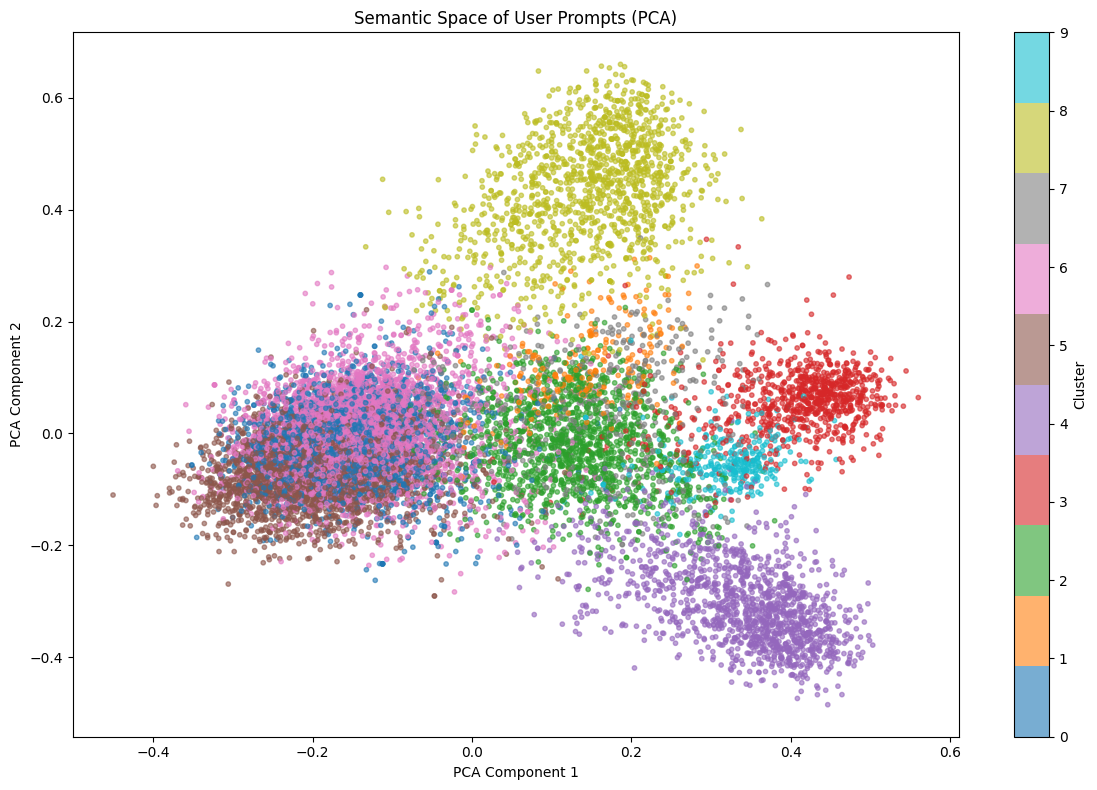

In [7]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2, random_state=42)
prompts_2d = pca.fit_transform(prompt_embeddings)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(prompts_2d[:, 0], prompts_2d[:, 1], 
                     c=df['prompt_cluster'], 
                     cmap='tab10', 
                     alpha=0.6, 
                     s=1)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Semantic Space of User Prompts (PCA)')
plt.tight_layout()
plt.show()


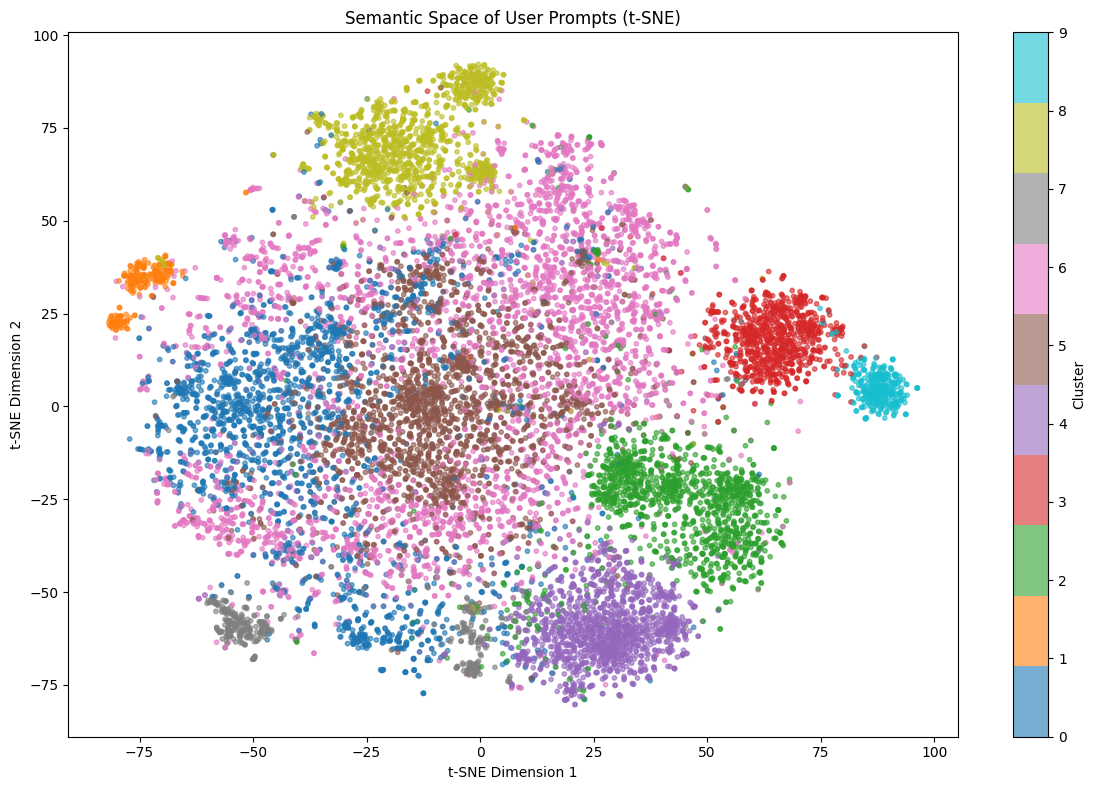

In [14]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Use t-SNE instead of UMAP
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
prompts_2d_tsne = tsne.fit_transform(prompt_embeddings)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(prompts_2d_tsne[:, 0], prompts_2d_tsne[:, 1], 
                     c=df['prompt_cluster'], 
                     cmap='tab10', 
                     alpha=0.6, 
                     s=10)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('Semantic Space of User Prompts (t-SNE)')
plt.tight_layout()
plt.show()

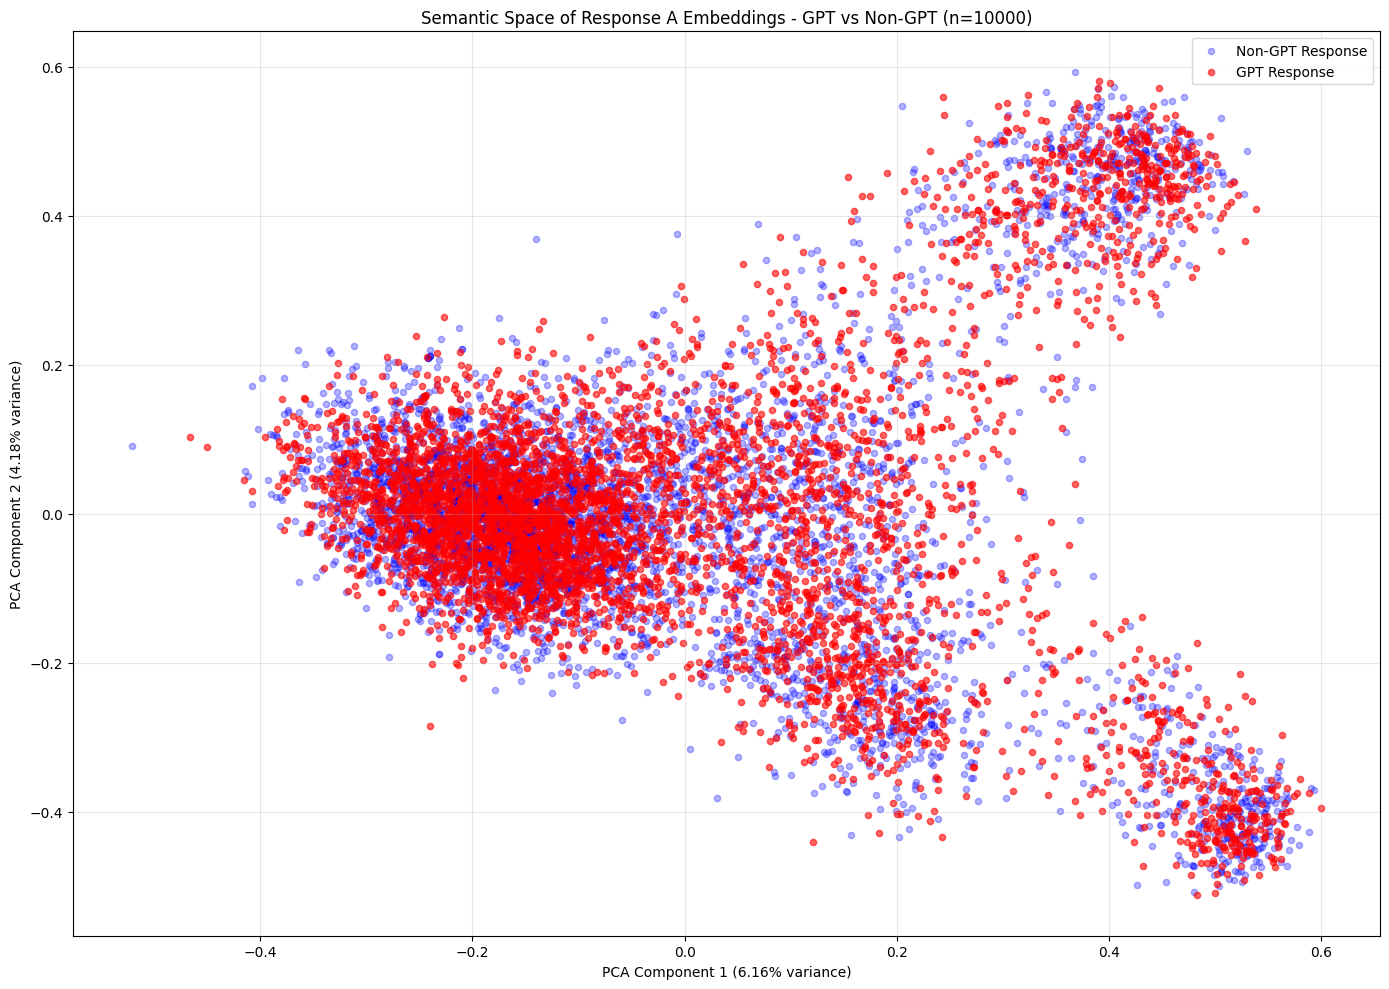

Sampled responses: 10000
GPT responses: 4983 (49.8%)
Non-GPT responses: 5017 (50.2%)


In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Downsample for better visualization
sample_size = min(10000, len(df))  # Adjust sample_size as needed
sample_indices = np.random.choice(len(df), sample_size, replace=False)

# Get response_a embeddings (downsampled)
response_a_sample = response_a_embeddings[sample_indices]

# Check which response_a samples are GPT
gpt_a_sample = df.iloc[sample_indices]['gpt_in_a'].values

# Reduce to 2D for visualization
pca = PCA(n_components=2, random_state=42)
responses_2d = pca.fit_transform(response_a_sample)

# Create the plot
plt.figure(figsize=(14, 10))

# Plot non-GPT responses in gray
non_gpt_mask = ~gpt_a_sample
plt.scatter(responses_2d[non_gpt_mask, 0], responses_2d[non_gpt_mask, 1], 
           c='blue', 
           alpha=0.3, 
           s=20,
           label='Non-GPT Response')

# Plot GPT responses in red
gpt_mask = gpt_a_sample
plt.scatter(responses_2d[gpt_mask, 0], responses_2d[gpt_mask, 1], 
           c='red', 
           alpha=0.6, 
           s=20,
           label='GPT Response')

plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'Semantic Space of Response A Embeddings - GPT vs Non-GPT (n={sample_size})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show statistics
print(f"Sampled responses: {sample_size}")
print(f"GPT responses: {gpt_mask.sum()} ({gpt_mask.sum()/sample_size*100:.1f}%)")
print(f"Non-GPT responses: {non_gpt_mask.sum()} ({non_gpt_mask.sum()/sample_size*100:.1f}%)")


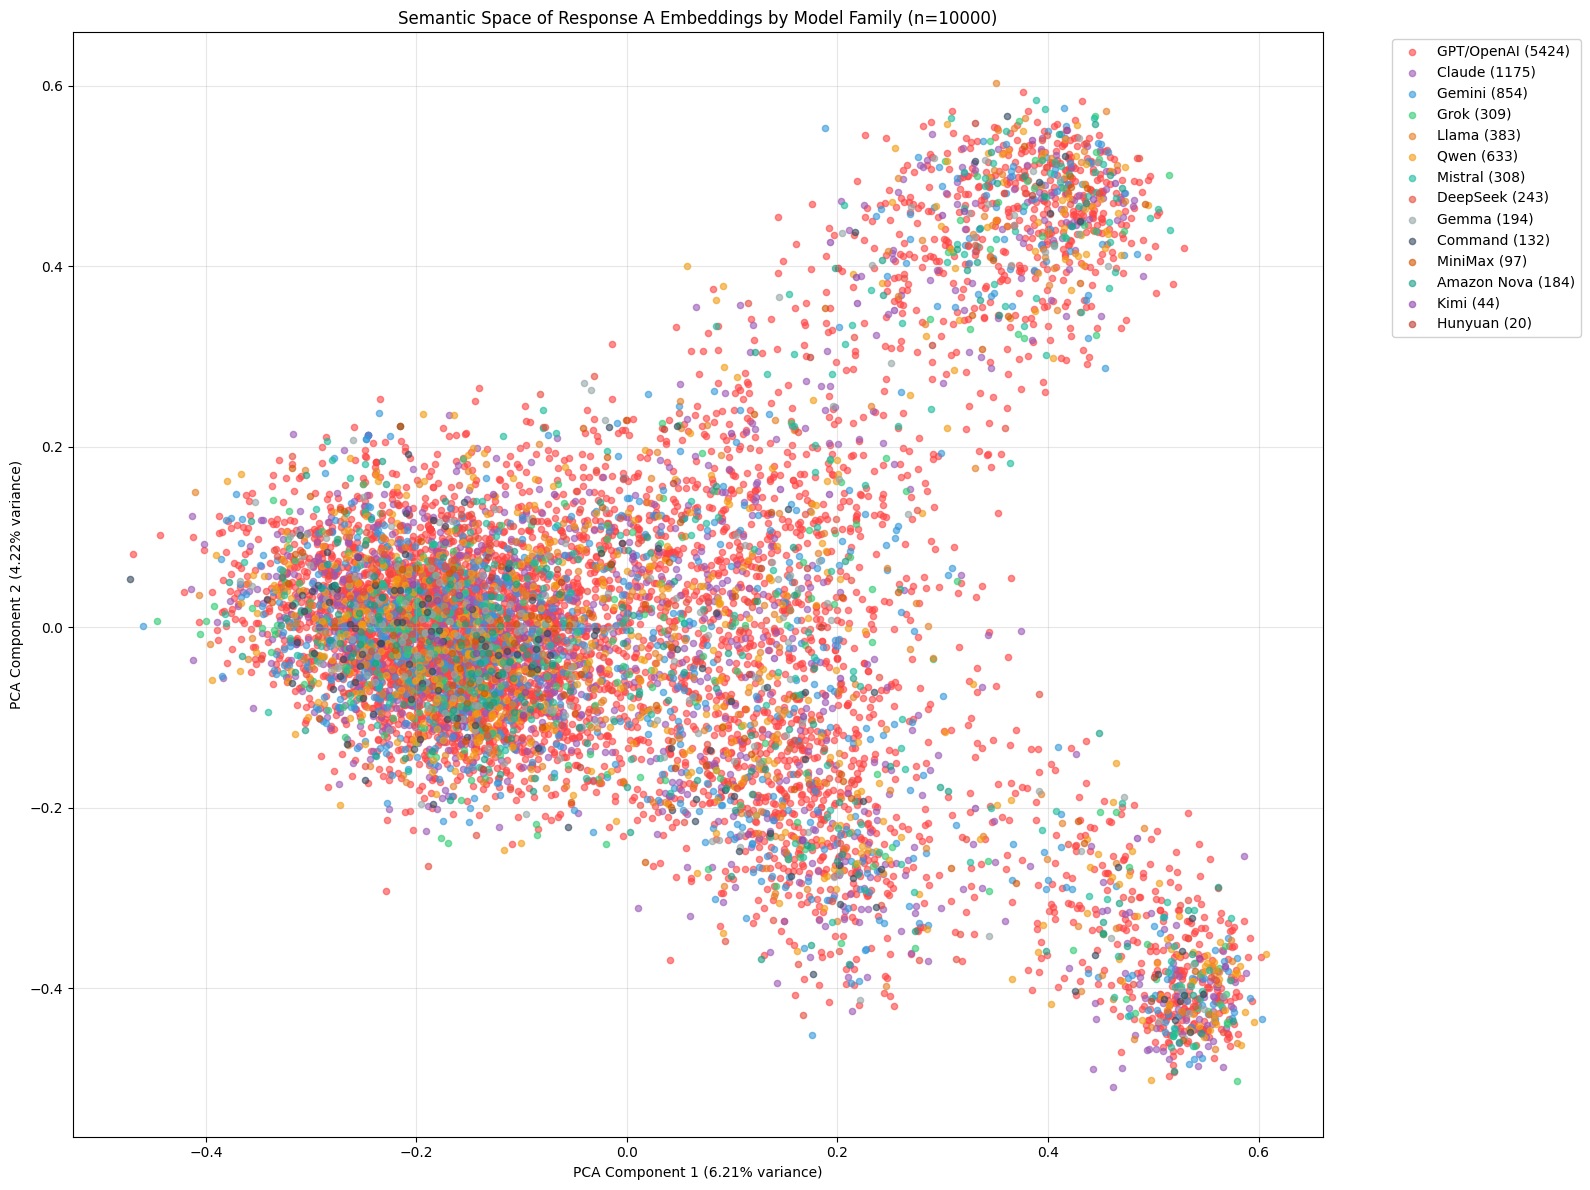

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Downsample
sample_size = min(10000, len(df))
sample_indices = np.random.choice(len(df), sample_size, replace=False)

# Get response_a embeddings and model names
response_a_sample = response_a_embeddings[sample_indices]
model_a_sample = df.iloc[sample_indices]['model_a'].values

# Reduce to 2D
pca = PCA(n_components=2, random_state=42)
responses_2d = pca.fit_transform(response_a_sample)

# Define model families and colors
def get_model_family(model_name):
    model_name = model_name.lower()
    if 'gpt' in model_name or 'o3' in model_name or 'o4' in model_name or 'chatgpt' in model_name:
        return 'GPT/OpenAI'
    elif 'claude' in model_name:
        return 'Claude'
    elif 'gemini' in model_name:
        return 'Gemini'
    elif 'grok' in model_name:
        return 'Grok'
    elif 'llama' in model_name:
        return 'Llama'
    elif 'qwen' in model_name or 'qwq' in model_name:
        return 'Qwen'
    elif 'mistral' in model_name or 'magistral' in model_name:
        return 'Mistral'
    elif 'deepseek' in model_name:
        return 'DeepSeek'
    elif 'gemma' in model_name:
        return 'Gemma'
    elif 'command' in model_name:
        return 'Command'
    elif 'minimax' in model_name:
        return 'MiniMax'
    elif 'nova' in model_name or 'amazon' in model_name:
        return 'Amazon Nova'
    elif 'kimi' in model_name:
        return 'Kimi'
    elif 'hunyuan' in model_name:
        return 'Hunyuan'
    else:
        return 'Other'

# Create family labels
families = np.array([get_model_family(m) for m in model_a_sample])

# Define color map
family_colors = {
    'GPT/OpenAI': '#FF4444',
    'Claude': '#9B59B6',
    'Gemini': '#3498DB',
    'Grok': '#2ECC71',
    'Llama': '#E67E22',
    'Qwen': '#F39C12',
    'Mistral': '#1ABC9C',
    'DeepSeek': '#E74C3C',
    'Gemma': '#95A5A6',
    'Command': '#34495E',
    'MiniMax': '#D35400',
    'Amazon Nova': '#16A085',
    'Kimi': '#8E44AD',
    'Hunyuan': '#C0392B',
    'Other': '#7F8C8D'
}

# Create the plot
plt.figure(figsize=(16, 12))

for family, color in family_colors.items():
    mask = families == family
    if mask.sum() > 0:
        plt.scatter(responses_2d[mask, 0], responses_2d[mask, 1], 
                   c=color, 
                   alpha=0.6, 
                   s=20,
                   label=f'{family} ({mask.sum()})')

plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'Semantic Space of Response A Embeddings by Model Family (n={sample_size})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print("\nModel Family Distribution:")
unique_families, counts = np.unique(families, return_counts=True)
for family, count in sorted(zip(unique_families, counts), key=lambda x: -x[1]):
    print(f"{family:20s}: {count:5d} ({count/sample_size*100:5.1f}%)")


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Fitting PaCMAP...
Applied PCA, the dimensionality becomes 100
PaCMAP(n_neighbors=10, n_MN=5, n_FP=20, distance=euclidean, lr=1.0, n_iters=(100, 100, 250), apply_pca=True, opt_method='adam', verbose=True, intermediate=False, seed=None)
Finding pairs
Found nearest neighbor
Calculated sigma
Found scaled dist
Pairs sampled successfully.
((100000, 2), (50000, 2), (200000, 2))
Initial Loss: 123170.9765625
Iteration:   10, Loss: 85978.593750
Iteration:   20, Loss: 79861.203125
Iteration:   30, Loss: 76415.156250
Iteration:   40, Loss: 73440.054688
Iteration:   50, Loss: 70434.085938
Iteration:   60, Loss: 67168.890625
Iteration:   70, Loss: 63443.507812
Iteration:   80, Loss: 58973.445312
Iteration:   90, Loss: 53166.273438
Iteration:  100, Loss: 44345.472656
Iteration:  110, Loss: 55267.375000
Iteration:  120, Loss: 54928.031250
Iteration:  130, Loss: 54799.546875
Iteration:  140, Loss: 54742.398438
Iteration:  150, Loss: 54696.664062
Iteration:  160, Loss: 54655.054688
Iteration:  170, Loss

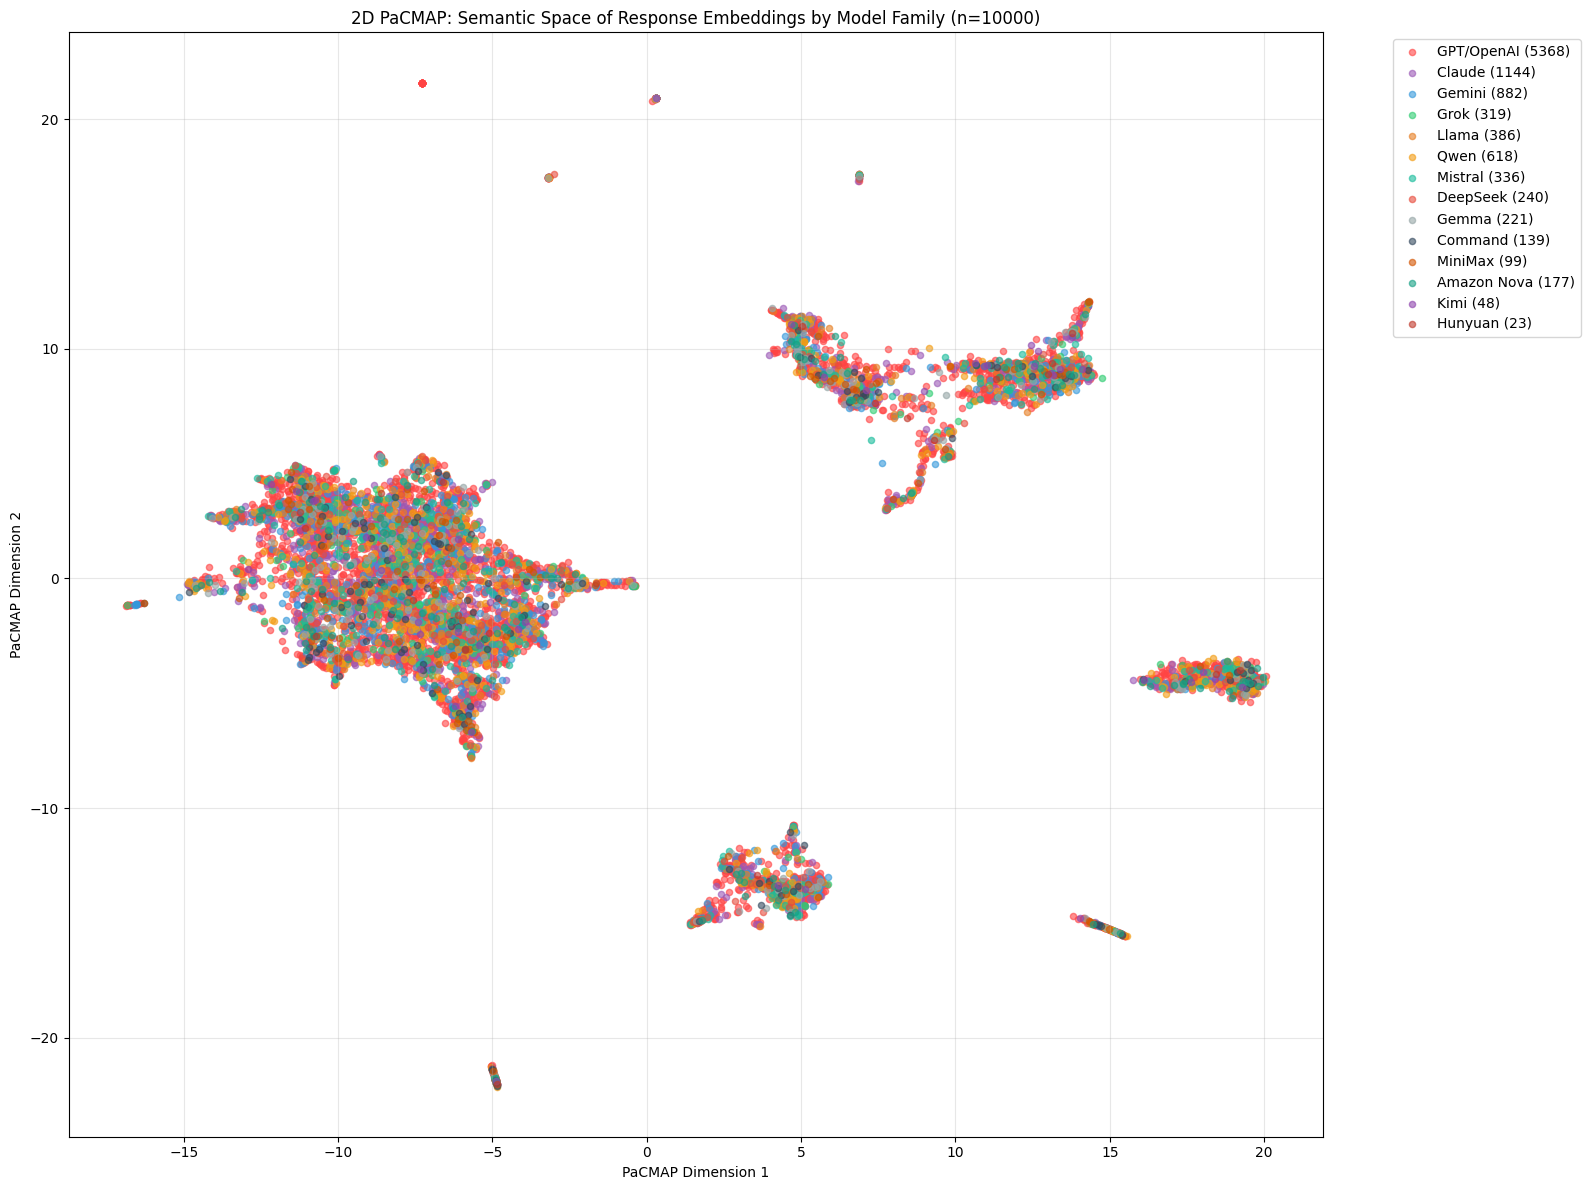


Model Family Distribution:
GPT/OpenAI          :  5368 ( 53.7%)
Claude              :  1144 ( 11.4%)
Gemini              :   882 (  8.8%)
Qwen                :   618 (  6.2%)
Llama               :   386 (  3.9%)
Mistral             :   336 (  3.4%)
Grok                :   319 (  3.2%)
DeepSeek            :   240 (  2.4%)
Gemma               :   221 (  2.2%)
Amazon Nova         :   177 (  1.8%)
Command             :   139 (  1.4%)
MiniMax             :    99 (  1.0%)
Kimi                :    48 (  0.5%)
Hunyuan             :    23 (  0.2%)


In [31]:
# Install PaCMAP (if not already installed)
!pip install pacmap

# Import libraries
import pacmap
import matplotlib.pyplot as plt
import numpy as np

# Downsample
sample_size = min(10000, len(df))
sample_indices = np.random.choice(len(df), sample_size, replace=False)

# Get response_a embeddings and model names
response_a_sample = response_a_embeddings[sample_indices]
model_a_sample = df.iloc[sample_indices]['model_a'].values

# Configure PaCMAP for 2D
print("Fitting PaCMAP...")
embedding = pacmap.PaCMAP(
    n_components=2, 
    n_neighbors=10, 
    MN_ratio=0.5, 
    FP_ratio=2.0,
    verbose=True
)
responses_2d = embedding.fit_transform(response_a_sample, init="pca")
print("PaCMAP fitting complete!")

# Define model families
def get_model_family(model_name):
    model_name = model_name.lower()
    if 'gpt' in model_name or 'o3' in model_name or 'o4' in model_name or 'chatgpt' in model_name:
        return 'GPT/OpenAI'
    elif 'claude' in model_name:
        return 'Claude'
    elif 'gemini' in model_name:
        return 'Gemini'
    elif 'grok' in model_name:
        return 'Grok'
    elif 'llama' in model_name:
        return 'Llama'
    elif 'qwen' in model_name or 'qwq' in model_name:
        return 'Qwen'
    elif 'mistral' in model_name or 'magistral' in model_name:
        return 'Mistral'
    elif 'deepseek' in model_name:
        return 'DeepSeek'
    elif 'gemma' in model_name:
        return 'Gemma'
    elif 'command' in model_name:
        return 'Command'
    elif 'minimax' in model_name:
        return 'MiniMax'
    elif 'nova' in model_name or 'amazon' in model_name:
        return 'Amazon Nova'
    elif 'kimi' in model_name:
        return 'Kimi'
    elif 'hunyuan' in model_name:
        return 'Hunyuan'
    else:
        return 'Other'

families = np.array([get_model_family(m) for m in model_a_sample])

# Define color map
family_colors = {
    'GPT/OpenAI': '#FF4444',
    'Claude': '#9B59B6',
    'Gemini': '#3498DB',
    'Grok': '#2ECC71',
    'Llama': '#E67E22',
    'Qwen': '#F39C12',
    'Mistral': '#1ABC9C',
    'DeepSeek': '#E74C3C',
    'Gemma': '#95A5A6',
    'Command': '#34495E',
    'MiniMax': '#D35400',
    'Amazon Nova': '#16A085',
    'Kimi': '#8E44AD',
    'Hunyuan': '#C0392B',
    'Other': '#7F8C8D'
}

# Create 2D plot
plt.figure(figsize=(16, 12))

for family, color in family_colors.items():
    mask = families == family
    if mask.sum() > 0:
        plt.scatter(responses_2d[mask, 0], 
                   responses_2d[mask, 1],
                   c=color, 
                   alpha=0.6, 
                   s=20,
                   label=f'{family} ({mask.sum()})')

plt.xlabel('PaCMAP Dimension 1')
plt.ylabel('PaCMAP Dimension 2')
plt.title(f'2D PaCMAP: Semantic Space of Response Embeddings by Model Family (n={sample_size})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print("\nModel Family Distribution:")
unique_families, counts = np.unique(families, return_counts=True)
for family, count in sorted(zip(unique_families, counts), key=lambda x: -x[1]):
    print(f"{family:20s}: {count:5d} ({count/sample_size*100:5.1f}%)")


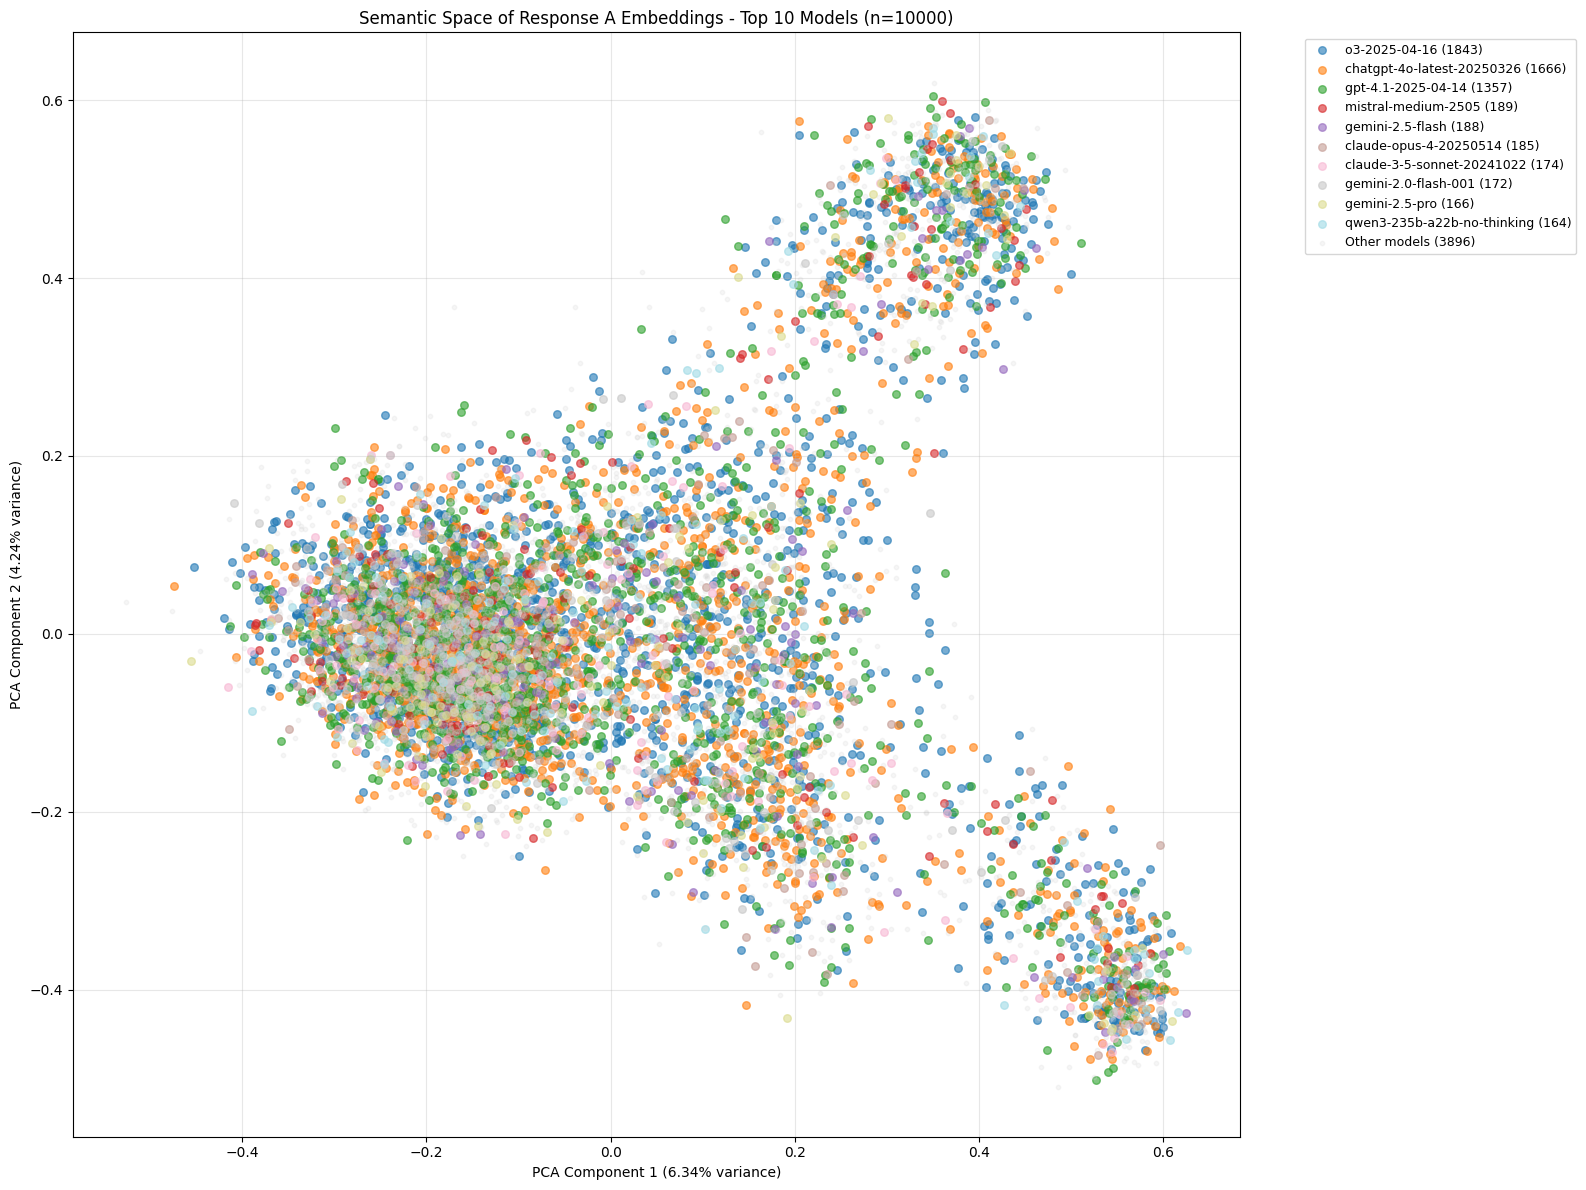

In [21]:
# Visualize top 10 most frequent models
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Downsample
sample_size = min(10000, len(df))
sample_indices = np.random.choice(len(df), sample_size, replace=False)

response_a_sample = response_a_embeddings[sample_indices]
model_a_sample = df.iloc[sample_indices]['model_a'].values

# Get top 10 models
from collections import Counter
model_counts = Counter(model_a_sample)
top_models = [m for m, _ in model_counts.most_common(10)]

# Reduce to 2D
pca = PCA(n_components=2, random_state=42)
responses_2d = pca.fit_transform(response_a_sample)

# Create the plot
plt.figure(figsize=(16, 12))
colors = plt.cm.tab20(np.linspace(0, 1, 10))

for idx, model in enumerate(top_models):
    mask = model_a_sample == model
    if mask.sum() > 0:
        plt.scatter(responses_2d[mask, 0], responses_2d[mask, 1], 
                   c=[colors[idx]], 
                   alpha=0.6, 
                   s=30,
                   label=f'{model} ({mask.sum()})')

# Plot "Other" models in gray
other_mask = ~np.isin(model_a_sample, top_models)
plt.scatter(responses_2d[other_mask, 0], responses_2d[other_mask, 1], 
           c='lightgray', 
           alpha=0.2, 
           s=10,
           label=f'Other models ({other_mask.sum()})')

plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'Semantic Space of Response A Embeddings - Top 10 Models (n={sample_size})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Fitting 3D t-SNE (this may take 1-2 minutes)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.001s...
[t-SNE] Computed neighbors for 5000 samples in 0.315s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 0.269503
[t-SNE] KL divergence after 250 iterations with early exaggeration: 86.357811
[t-SNE] KL divergence after 1000 iterations: 1.844834
t-SNE fitting complete!


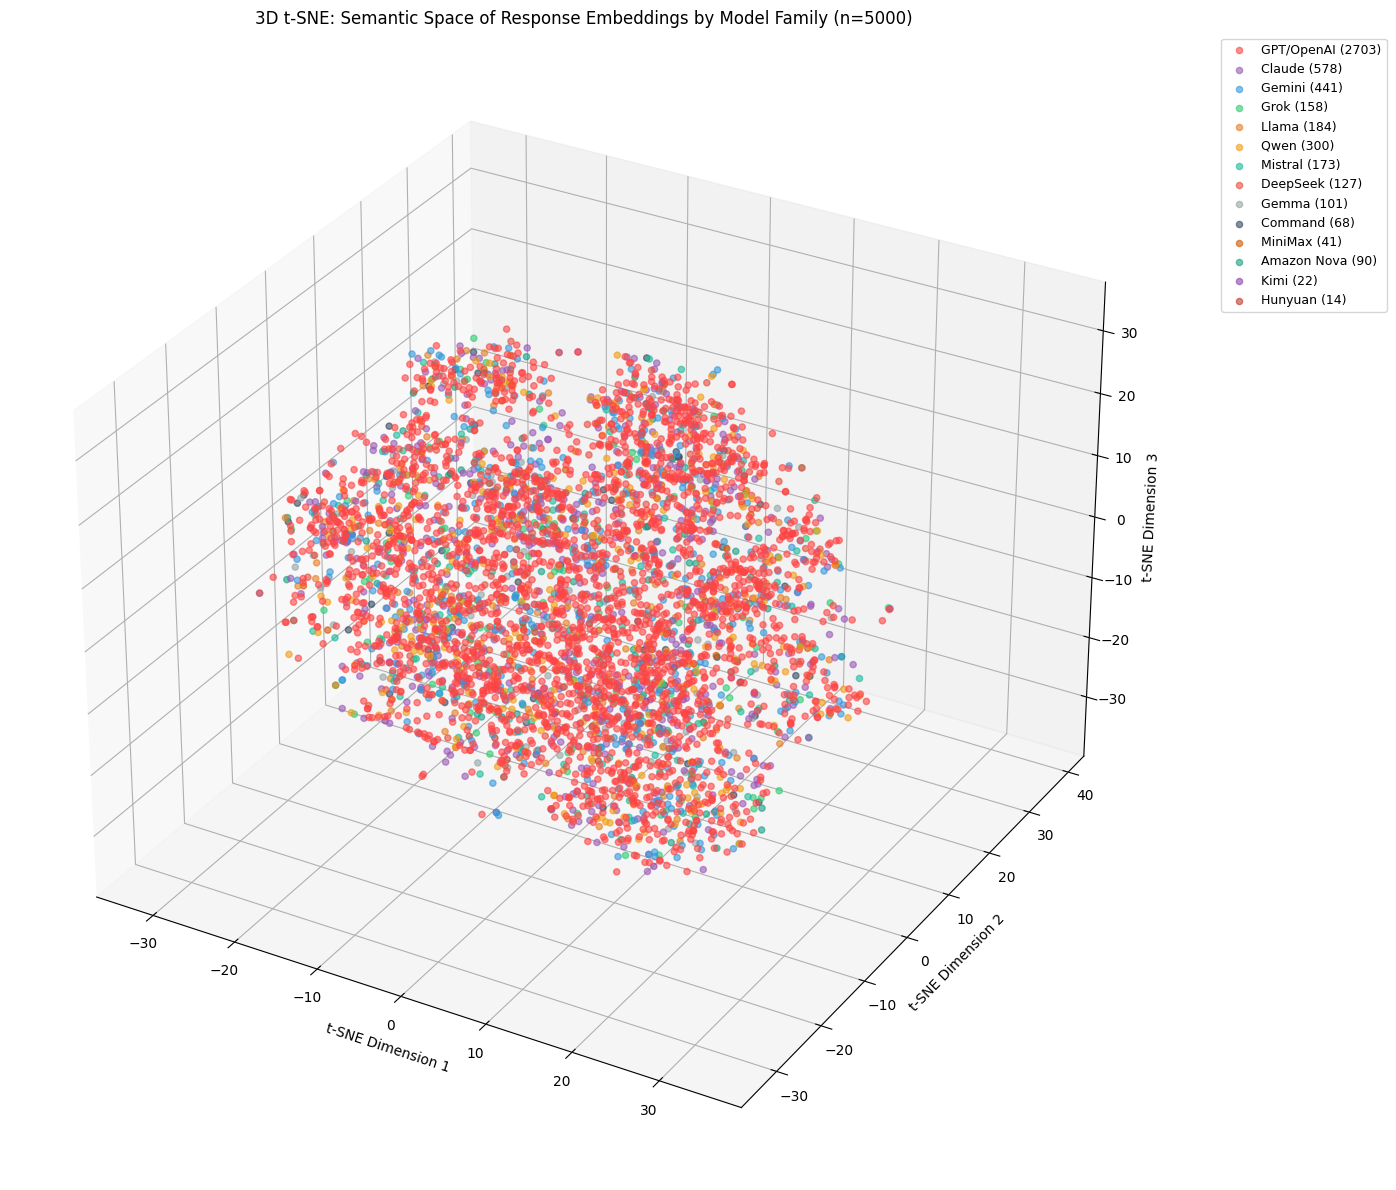

In [32]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Downsample for t-SNE (it's slower than UMAP)
sample_size = min(5000, len(df))
sample_indices = np.random.choice(len(df), sample_size, replace=False)

response_a_sample = response_a_embeddings[sample_indices]
model_a_sample = df.iloc[sample_indices]['model_a'].values

# Use t-SNE for 3D
print("Fitting 3D t-SNE (this may take 1-2 minutes)...")
tsne = TSNE(n_components=3, random_state=42, perplexity=30, n_iter=1000, verbose=1)
responses_3d = tsne.fit_transform(response_a_sample)
print("t-SNE fitting complete!")

# Define model families (same function as before)
def get_model_family(model_name):
    model_name = model_name.lower()
    if 'gpt' in model_name or 'o3' in model_name or 'o4' in model_name or 'chatgpt' in model_name:
        return 'GPT/OpenAI'
    elif 'claude' in model_name:
        return 'Claude'
    elif 'gemini' in model_name:
        return 'Gemini'
    elif 'grok' in model_name:
        return 'Grok'
    elif 'llama' in model_name:
        return 'Llama'
    elif 'qwen' in model_name or 'qwq' in model_name:
        return 'Qwen'
    elif 'mistral' in model_name or 'magistral' in model_name:
        return 'Mistral'
    elif 'deepseek' in model_name:
        return 'DeepSeek'
    elif 'gemma' in model_name:
        return 'Gemma'
    elif 'command' in model_name:
        return 'Command'
    elif 'minimax' in model_name:
        return 'MiniMax'
    elif 'nova' in model_name or 'amazon' in model_name:
        return 'Amazon Nova'
    elif 'kimi' in model_name:
        return 'Kimi'
    elif 'hunyuan' in model_name:
        return 'Hunyuan'
    else:
        return 'Other'

families = np.array([get_model_family(m) for m in model_a_sample])

family_colors = {
    'GPT/OpenAI': '#FF4444',
    'Claude': '#9B59B6',
    'Gemini': '#3498DB',
    'Grok': '#2ECC71',
    'Llama': '#E67E22',
    'Qwen': '#F39C12',
    'Mistral': '#1ABC9C',
    'DeepSeek': '#E74C3C',
    'Gemma': '#95A5A6',
    'Command': '#34495E',
    'MiniMax': '#D35400',
    'Amazon Nova': '#16A085',
    'Kimi': '#8E44AD',
    'Hunyuan': '#C0392B',
    'Other': '#7F8C8D'
}

# Create 3D plot
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

for family, color in family_colors.items():
    mask = families == family
    if mask.sum() > 0:
        ax.scatter(responses_3d[mask, 0], 
                  responses_3d[mask, 1], 
                  responses_3d[mask, 2],
                  c=color, 
                  alpha=0.6, 
                  s=20,
                  label=f'{family} ({mask.sum()})')

ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.set_zlabel('t-SNE Dimension 3')
ax.set_title(f'3D t-SNE: Semantic Space of Response Embeddings by Model Family (n={sample_size})')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()
